In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

In [110]:
df = pd.read_csv("dataset.csv")
df.head()

,md5,sha1,file_extension,EntryPoint,PEType,MachineType,magic_number,bytes_on_last_page,pages_in_file,relocations,...,total_procsses,files_malicious,files_suspicious,files_text,files_unknown,dlls_calls,apis,Class,Category,Family
0,d5aa2b2506dd71b65307bb551a6a099d,62f4d55a1bb8396e493d7815dc44febed7161535,exe,0x108ec,PE32+,AMD AMD64,MZ,0x0090,0x0003,0x0000,...,0,0,0,0,0,6,162,Benign,Benign,Benign
1,8d1178cec97f96a9ede3efe2f30ef30e,ca40945a4e35d48794a5e13aacf16b8ae1caddeb,exe,0x25cf9c,PE32+,AMD AMD64,MZ,0x0090,0x0003,0x0000,...,93,0,0,0,0,22,778,Benign,Benign,Benign
2,c08d7afb7966f452cf5aa9283fe8880a,6f47b50480bea61ae4dfb75c12582990cc5ce770,exe,0x2a7e,PE32,"Intel 386 or later, and compatibles",MZ,0x0090,0x0003,0x0000,...,35,0,0,0,0,1,1,Benign,Benign,Benign
3,3554a3a99e7ffb57552aedcb2520f1d2,8c3d5b506a8d55f42f4c83ead3e4341255d1acfc,exe,0x64ca0,PE32+,AMD AMD64,MZ,0x0090,0x0003,0x0004,...,0,0,0,0,0,1,40,Benign,Benign,Benign
4,5be9511d42136df49d9501680e84109f,0a7d0c68c591db2f197b2169d226bebe6e9bdabe,exe,0x1b9ae,PE32,"Intel 386 or later, and compatibles",MZ,0x0090,0x0003,0x0000,...,36,0,0,0,0,1,1,Benign,Benign,Benign


In [111]:
df.tail()

,md5,sha1,file_extension,EntryPoint,PEType,MachineType,magic_number,bytes_on_last_page,pages_in_file,relocations,...,total_procsses,files_malicious,files_suspicious,files_text,files_unknown,dlls_calls,apis,Class,Category,Family
21747,3aabbbed7dd5e3589f2387ec1a62471f,067d84bef48f6abc37226c6ccb981d21f7c8b93f,exe,0x889b6,PE32,"Intel 386 or later, and compatibles",MZ,0x0090,0x0003,0x0000,...,29,0,0,0,0,1,1,Malware,Stealer,Snake
21748,c62343c3c6463795e88fe0a2a81c82b3,02df1939b04bc7de83c3029c5eb8e9b25cc9be91,exe,0x9a2f2,PE32,"Intel 386 or later, and compatibles",MZ,0x0090,0x0003,0x0000,...,32,0,0,0,0,1,1,Malware,Stealer,Snake
21749,db92e74aee2f64a0b40a64c1a014e257,fde61811f7ae53f9fa59e17fb5c2c6143a48b282,exe,0x9a2f2,PE32,"Intel 386 or later, and compatibles",MZ,0x0090,0x0003,0x0000,...,35,0,0,0,0,1,1,Malware,Stealer,Snake
21750,06e50d688d5b79ffea6135c7a55402cd,ad58274e8425775b284ee1f314f879100d437340,exe,0x9a2f2,PE32,"Intel 386 or later, and compatibles",MZ,0x0090,0x0003,0x0000,...,29,0,0,0,0,1,1,Malware,Stealer,Snake
21751,981de70f5242ac1192bf182be3797e1b,d7ac568899333c823c589444286f9d3655992332,exe,0xa13ae,PE32,"Intel 386 or later, and compatibles",MZ,0x0090,0x0003,0x0000,...,33,1,0,1,0,0,0,Malware,Stealer,Snake


In [112]:
df.shape

(21752, 77)

In [113]:
df.duplicated().sum()

0

In [114]:
df.isnull().sum()

md5               0
sha1              0
file_extension    0
EntryPoint        0
PEType            0
                 ..
dlls_calls        0
apis              0
Class             0
Category          0
Family            0
Length: 77, dtype: int64

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21752 entries, 0 to 21751
Data columns (total 77 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   md5                         21752 non-null  object
 1   sha1                        21752 non-null  object
 2   file_extension              21752 non-null  object
 3   EntryPoint                  21752 non-null  object
 4   PEType                      21752 non-null  object
 5   MachineType                 21752 non-null  object
 6   magic_number                21752 non-null  object
 7   bytes_on_last_page          21752 non-null  object
 8   pages_in_file               21752 non-null  object
 9   relocations                 21752 non-null  object
 10  size_of_header              21752 non-null  object
 11  min_extra_paragraphs        21752 non-null  object
 12  max_extra_paragraphs        21752 non-null  object
 13  init_ss_value               21752 non-null  ob

In [116]:
df.describe()

,registry_read,registry_write,registry_delete,registry_total,network_threats,network_dns,network_http,network_connections,processes_malicious,processes_suspicious,processes_monitored,total_procsses,files_malicious,files_suspicious,files_text,files_unknown,dlls_calls,apis
count,2.175200e+04,21752.000000,21752.000000,2.175200e+04,21752.0,21752.000000,21752.000000,21752.000000,21752.000000,21752.000000,21752.000000,21752.000000,21752.00000,21752.000000,21752.000000,21752.000000,21752.000000,21752.000000
mean,2.171168e+03,25.674053,3.680627,2.276478e+03,0.0,4.852657,1.844014,22.136861,1.820614,0.342497,8.272113,42.581602,8.36507,356.610656,72.548777,29.032135,4.621828,95.685408
std,2.409530e+04,294.948577,96.000378,2.421555e+04,0.0,39.940747,31.480131,220.420601,15.786036,3.082385,41.677590,51.766211,44.64347,1965.171138,371.995907,225.768247,5.784234,161.853316
min,0.000000e+00,0.000000,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.400000e+01,0.000000,0.000000,2.100000e+01,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,34.000000,0.00000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,2.960000e+02,0.000000,0.000000,2.710000e+02,0.0,0.000000,0.000000,2.000000,1.000000,0.000000,2.000000,37.000000,0.00000,0.000000,0.000000,0.000000,2.000000,32.000000
75%,9.892500e+02,3.000000,0.000000,1.082250e+03,0.0,1.000000,0.000000,6.000000,2.000000,0.000000,6.000000,44.000000,1.00000,4.000000,3.000000,1.000000,7.000000,127.000000
max,1.785397e+06,25409.000000,12609.000000,1.785649e+06,0.0,1339.000000,3846.000000,16407.000000,1350.000000,229.000000,3247.000000,3295.000000,1104.00000,63152.000000,9951.000000,14075.000000,134.000000,3575.000000


In [117]:
df.nunique()

md5               13903
sha1              13904
file_extension        1
EntryPoint         8325
PEType                3
                  ...  
dlls_calls           58
apis                769
Class                 2
Category              5
Family               27
Length: 77, dtype: int64

In [118]:
df.drop(columns=['md5', 'sha1'], inplace=True)

y_class = df['Class'].apply(lambda x: 1 if x != 'Benign' else 0)  
y_family = df['Family']

X = df.drop(columns=['Class', 'Category', 'Family'])

def convert_hex(val):
    try:
        if isinstance(val, str) and val.startswith("0x"):
            return int(val, 16)
        return int(val)
    except:
        return val

X = X.applymap(convert_hex)
X = pd.get_dummies(X)
X_selected = X  
le = LabelEncoder()
y_family_encoded = le.fit_transform(y_family)

C:\Users\Keerthi\AppData\Local\Temp\ipykernel_2416\4032234773.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = X.applymap(convert_hex)


In [119]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

selector_model = RandomForestClassifier(n_estimators=100, random_state=42)
selector_model.fit(X, y_class)

importances = selector_model.feature_importances_
feature_names = X.columns

top_k = 10
top_k_indices = np.argsort(importances)[-top_k:]
top_k_features = feature_names.to_numpy()[top_k_indices]
X_selected = X[top_k_features]

print("\nTop", top_k, "features used:")
for feature in top_k_features:
    print("-", feature)



Top 10 features used:
- network_http
- files_unknown
- total_procsses
- network_dns
- files_suspicious
- registry_read
- processes_monitored
- registry_total
- files_malicious
- processes_malicious


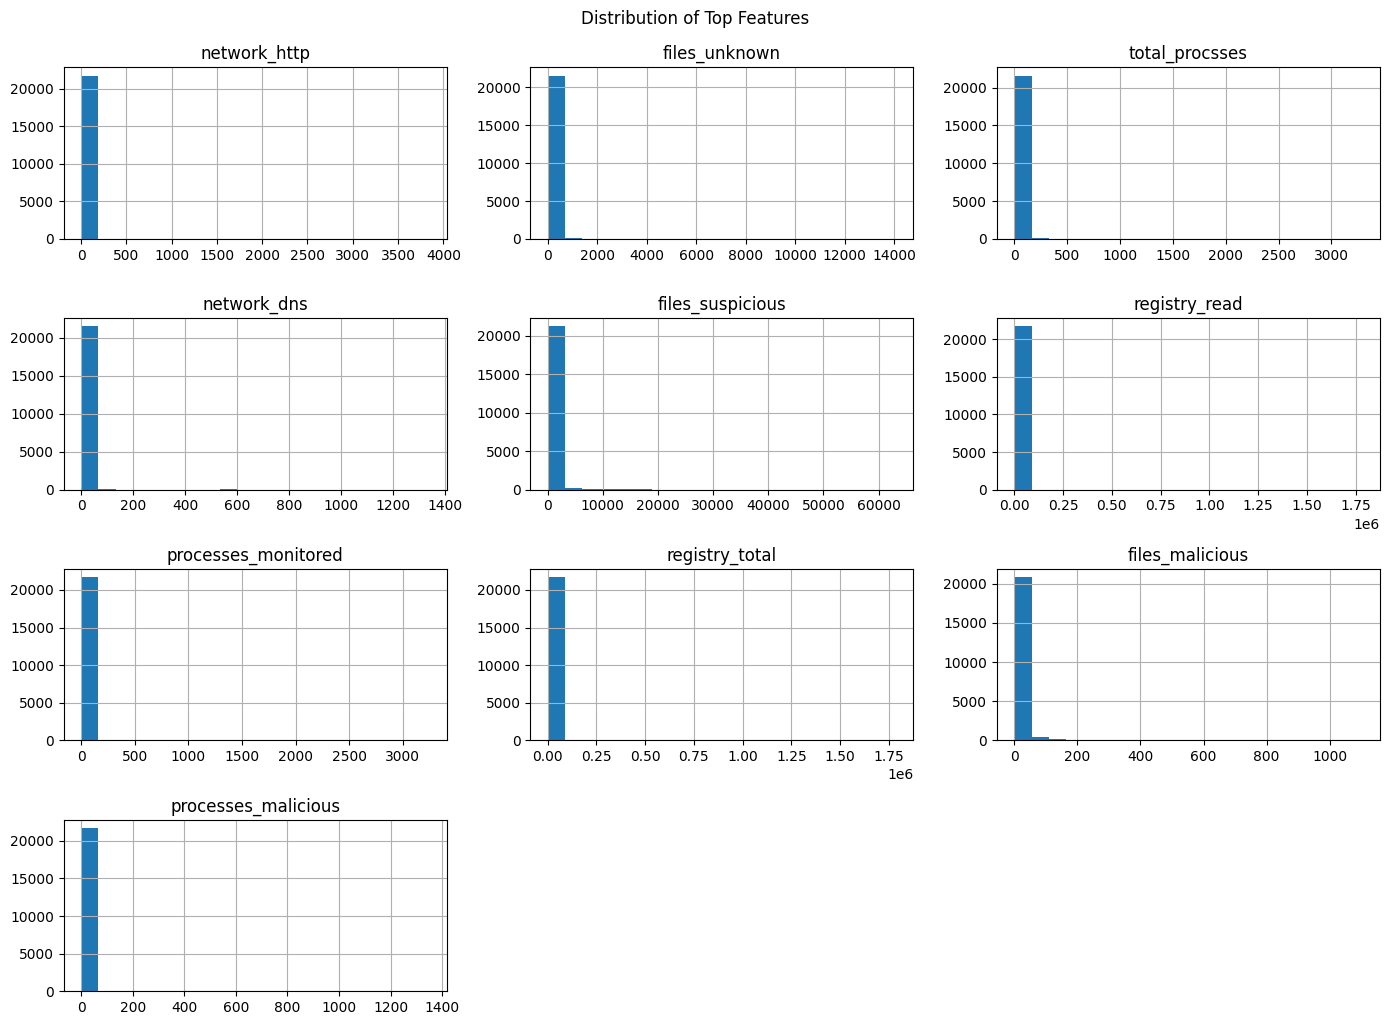

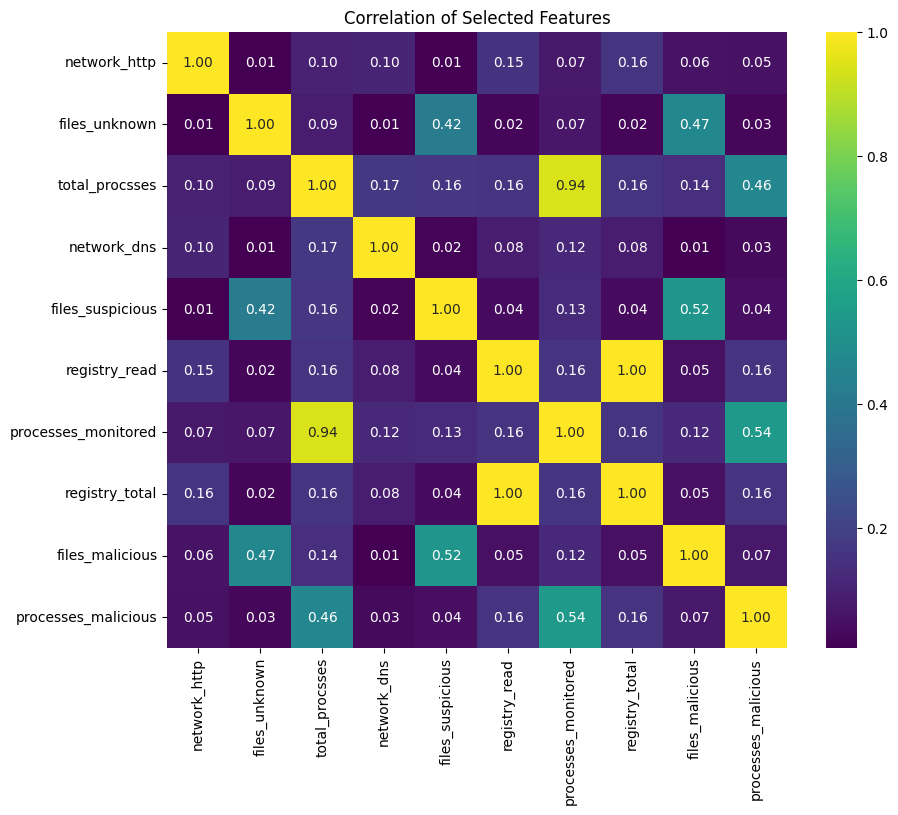

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

X_selected.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.suptitle("Distribution of Top Features", y=1.02)
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(X_selected.corr(), annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation of Selected Features")
plt.show()


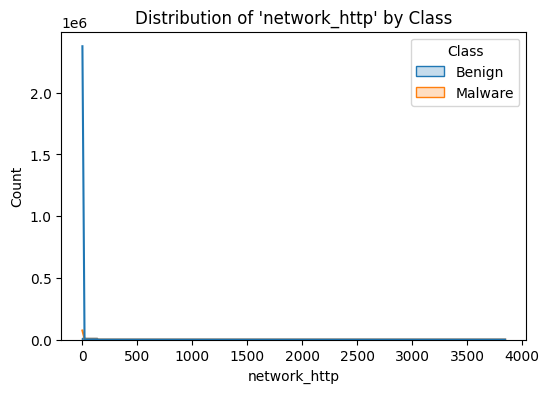

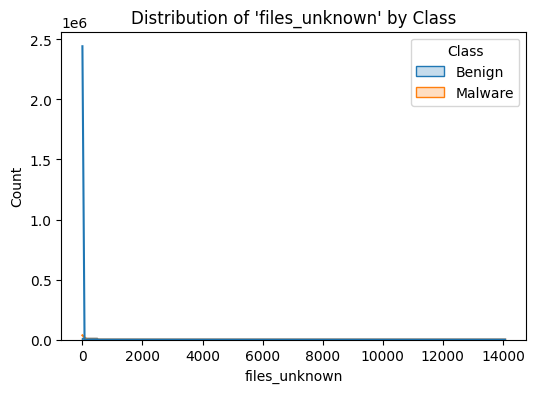

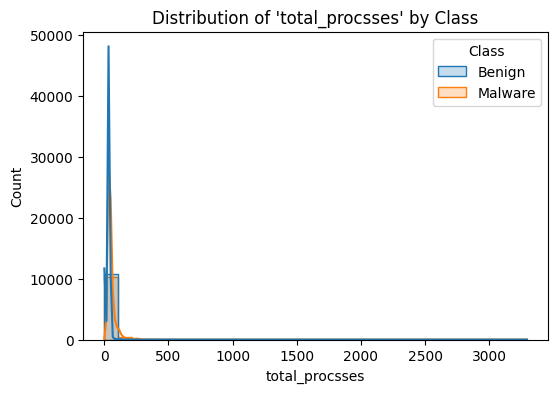

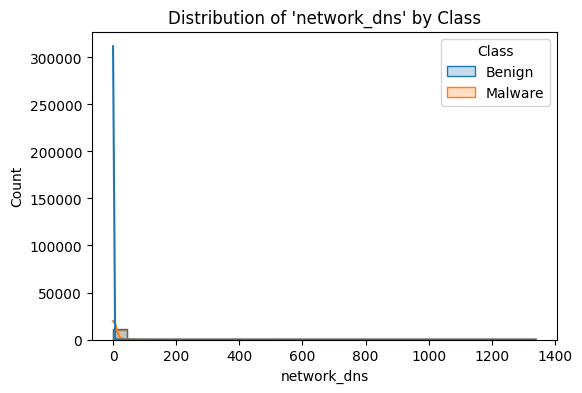

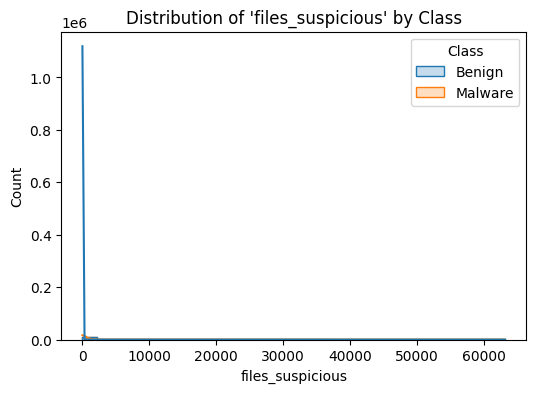

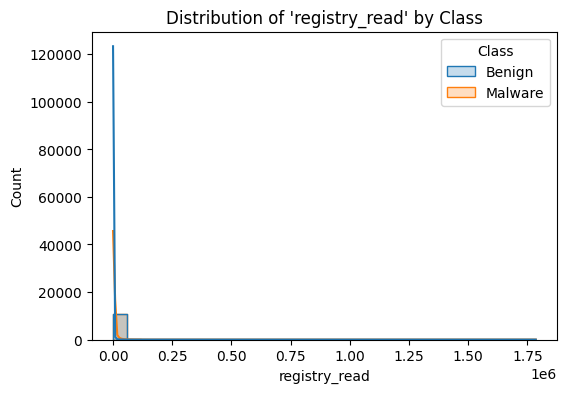

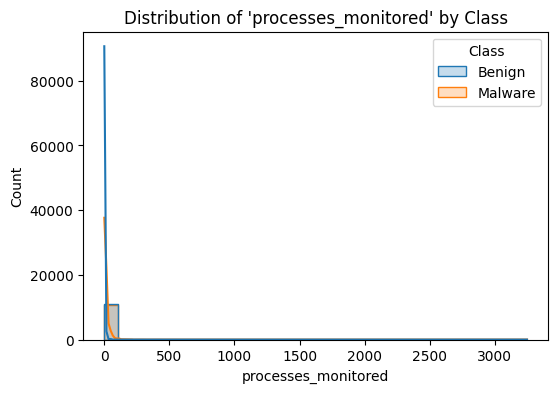

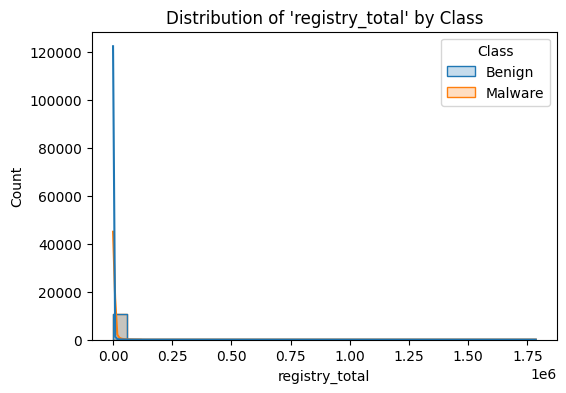

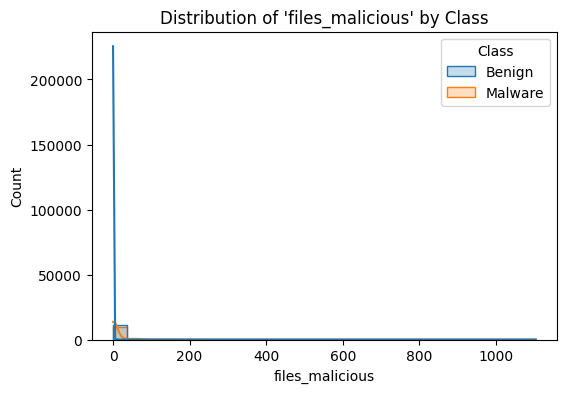

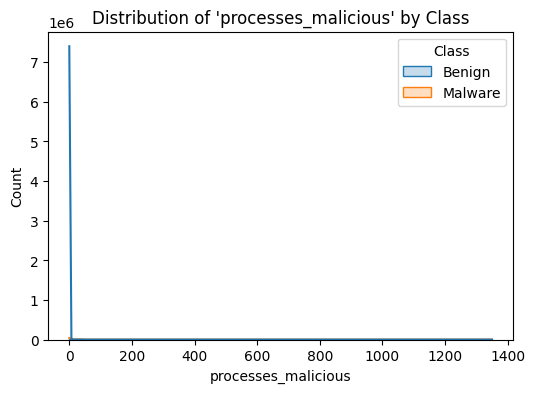

In [121]:
for feature in top_k_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=feature, hue='Class', bins=30, kde=True, element='step', common_norm=False)
    plt.title(f"Distribution of '{feature}' by Class")
    plt.show()

In [122]:
import numpy as np
X_selected_log = X_selected.copy()
for col in X_selected.columns:
    X_selected_log[col] = np.log1p(X_selected_log[col])  
print(X_selected_log)

       network_http  files_unknown  total_procsses  network_dns  \
0          0.000000            0.0        0.000000     0.000000   
1          0.693147            0.0        4.543295     1.098612   
2          0.000000            0.0        3.583519     0.000000   
3          0.000000            0.0        0.000000     0.000000   
4          0.000000            0.0        3.610918     0.000000   
...             ...            ...             ...          ...   
21747      0.693147            0.0        3.401197     1.098612   
21748      0.693147            0.0        3.496508     1.098612   
21749      0.693147            0.0        3.583519     1.098612   
21750      0.693147            0.0        3.401197     1.098612   
21751      0.693147            0.0        3.526361     1.386294   

       files_suspicious  registry_read  processes_monitored  registry_total  \
0                   0.0       0.000000             0.000000        0.000000   
1                   0.0       1.79175

In [123]:
object_columns = df.select_dtypes(include=['object']).columns
print("Object type columns:")
print(object_columns)

numerical_columns = df.select_dtypes(include=['int64']).columns
print("\nNumerical type columns:")
print(numerical_columns)

Object type columns:
Index(['file_extension', 'EntryPoint', 'PEType', 'MachineType', 'magic_number',
       'bytes_on_last_page', 'pages_in_file', 'relocations', 'size_of_header',
       'min_extra_paragraphs', 'max_extra_paragraphs', 'init_ss_value',
       'init_sp_value', 'init_ip_value', 'init_cs_value', 'over_lay_number',
       'oem_identifier', 'address_of_ne_header', 'Magic', 'SizeOfCode',
       'SizeOfInitializedData', 'SizeOfUninitializedData',
       'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase',
       'SectionAlignment', 'FileAlignment', 'OperatingSystemVersion',
       'ImageVersion', 'SizeOfImage', 'SizeOfHeaders', 'Checksum', 'Subsystem',
       'DllCharacteristics', 'SizeofStackReserve', 'SizeofStackCommit',
       'SizeofHeapCommit', 'SizeofHeapReserve', 'LoaderFlags',
       'text_VirtualSize', 'text_VirtualAddress', 'text_SizeOfRawData',
       'text_PointerToRawData', 'text_PointerToRelocations',
       'text_PointerToLineNumbers', 'text_Character

In [124]:
def classify_features(df):
    categorical_features = []
    non_categorical_features = []
    discrete_features = []
    continuous_features = []

    for column in df.columns:
        if df[column].dtype == 'object':
            if df[column].nunique() < 30:
                categorical_features.append(column)
            else:
                non_categorical_features.append(column)
        elif df[column].dtype in ['int64', 'float64']:
            if df[column].nunique() < 30:
                discrete_features.append(column)
            else:
                continuous_features.append(column)

    return categorical_features, non_categorical_features, discrete_features, continuous_features

In [125]:
categorical_features,non_categorical_features,discrete_features,continuous_features = classify_features(df)
print("Categorical Features:",categorical_features)
print("Non-Categorical Features:",non_categorical_features)
print("Discrete Features:",discrete_features)
print("Continuous Features:",continuous_features)

Categorical Features: ['file_extension', 'PEType', 'MachineType', 'magic_number', 'Magic', 'SectionAlignment', 'FileAlignment', 'OperatingSystemVersion', 'Subsystem', 'SizeofHeapCommit', 'SizeofHeapReserve', 'LoaderFlags', 'text_PointerToRelocations', 'text_PointerToLineNumbers', 'rdata_PointerToRelocations', 'rdata_PointerToLineNumbers', 'Class', 'Category', 'Family']
Non-Categorical Features: ['EntryPoint', 'bytes_on_last_page', 'pages_in_file', 'relocations', 'size_of_header', 'min_extra_paragraphs', 'max_extra_paragraphs', 'init_ss_value', 'init_sp_value', 'init_ip_value', 'init_cs_value', 'over_lay_number', 'oem_identifier', 'address_of_ne_header', 'SizeOfCode', 'SizeOfInitializedData', 'SizeOfUninitializedData', 'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase', 'ImageVersion', 'SizeOfImage', 'SizeOfHeaders', 'Checksum', 'DllCharacteristics', 'SizeofStackReserve', 'SizeofStackCommit', 'text_VirtualSize', 'text_VirtualAddress', 'text_SizeOfRawData', 'text_PointerToRaw

In [126]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [127]:
model_bin = DecisionTreeClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_bin, y_pred_bin = [], []

for train_idx, test_idx in cv.split(X_selected, y_class):
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = y_class.iloc[train_idx], y_class.iloc[test_idx]

    model_bin.fit(X_train, y_train)
    y_pred = model_bin.predict(X_test)

    y_true_bin.extend(y_test)
    y_pred_bin.extend(y_pred)

print("Classification Report of Decision Tree for Binary Classification:\n")
print(classification_report(y_true_bin, y_pred_bin))


Classification Report of Decision Tree for Binary Classification:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     10876
           1       0.99      0.99      0.99     10876

    accuracy                           0.99     21752
   macro avg       0.99      0.99      0.99     21752
weighted avg       0.99      0.99      0.99     21752



In [128]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report

rf_class = RandomForestClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_class, y_pred_class = [], []

for train_idx, test_idx in cv.split(X_selected, y_class):
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = y_class[train_idx], y_class[test_idx]  

    rf_class.fit(X_train, y_train)
    y_pred = rf_class.predict(X_test)

    y_true_class.extend(y_test)
    y_pred_class.extend(y_pred)

print("Classification Report of Random Forest for Binary Classification:\n")
print(classification_report(y_true_class, y_pred_class))


Classification Report of Random Forest for Binary Classification:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     10876
           1       0.99      1.00      0.99     10876

    accuracy                           0.99     21752
   macro avg       0.99      0.99      0.99     21752
weighted avg       0.99      0.99      0.99     21752



In [129]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

knn_class = KNeighborsClassifier(n_neighbors=5)

y_true_knn_class, y_pred_knn_class = [], []

for train_idx, test_idx in cv.split(X_selected, y_class):
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = y_class[train_idx], y_class[test_idx]  

    knn_class.fit(X_train, y_train)
    y_pred = knn_class.predict(X_test)

    y_true_knn_class.extend(y_test)
    y_pred_knn_class.extend(y_pred)

print("KNN Classification Report for Binary Classification:\n")
print(classification_report(y_true_knn_class, y_pred_knn_class))


KNN Classification Report for Binary Classification:

              precision    recall  f1-score   support

           0       0.93      0.91      0.92     10876
           1       0.91      0.93      0.92     10876

    accuracy                           0.92     21752
   macro avg       0.92      0.92      0.92     21752
weighted avg       0.92      0.92      0.92     21752



In [130]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb_class = XGBClassifier(eval_metric='logloss', random_state=42)
y_true_xgb_class, y_pred_xgb_class = [], []

for train_idx, test_idx in cv.split(X_selected, y_class):
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = y_class[train_idx], y_class[test_idx]

    xgb_class.fit(X_train, y_train)
    y_pred = xgb_class.predict(X_test)

    y_true_xgb_class.extend(y_test)
    y_pred_xgb_class.extend(y_pred)

print("XGBoost Classification Report for Binary Classification:\n")
print(classification_report(y_true_xgb_class, y_pred_xgb_class))


XGBoost Classification Report for Binary Classification:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     10876
           1       0.99      1.00      0.99     10876

    accuracy                           0.99     21752
   macro avg       0.99      0.99      0.99     21752
weighted avg       0.99      0.99      0.99     21752



In [131]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

model_family_dt = DecisionTreeClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_fam_dt, y_pred_fam_dt = [], []

for train_idx, test_idx in cv.split(X_selected, y_family_encoded):
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = y_family_encoded[train_idx], y_family_encoded[test_idx]

    model_family_dt.fit(X_train, y_train)
    y_pred = model_family_dt.predict(X_test)

    y_true_fam_dt.extend(y_test)
    y_pred_fam_dt.extend(y_pred)

print("\n--- Family Classification Report (Decision Tree) ---")
print(classification_report(y_true_fam_dt, y_pred_fam_dt))



--- Family Classification Report (Decision Tree) ---
              precision    recall  f1-score   support

           0       0.77      0.82      0.80       337
           1       0.99      0.99      0.99     10876
           2       0.81      0.84      0.82       332
           3       0.86      0.86      0.86       335
           4       0.84      0.86      0.85       505
           5       0.88      0.88      0.88       346
           6       0.85      0.85      0.85       473
           7       0.87      0.83      0.85       382
           8       0.69      0.69      0.69       454
           9       0.88      0.87      0.88       346
          10       0.82      0.84      0.83       444
          11       0.82      0.83      0.83       438
          12       0.88      0.88      0.88       290
          13       0.66      0.64      0.65       520
          14       0.92      0.90      0.91       550
          15       0.90      0.91      0.90       322
          16       0.84    

In [132]:

from sklearn.ensemble import RandomForestClassifier

rf_family = RandomForestClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_fam_rf, y_pred_fam_rf = [], []

for train_idx, test_idx in cv.split(X_selected, y_family_encoded):
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = y_family_encoded[train_idx], y_family_encoded[test_idx]

    rf_family.fit(X_train, y_train)
    y_pred = rf_family.predict(X_test)

    y_true_fam_rf.extend(y_test)
    y_pred_fam_rf.extend(y_pred)

print("\n--- Family Classification Report (Random Forest) ---")
print(classification_report(y_true_fam_rf, y_pred_fam_rf))



--- Family Classification Report (Random Forest) ---
              precision    recall  f1-score   support

           0       0.86      0.87      0.87       337
           1       0.99      0.99      0.99     10876
           2       0.86      0.89      0.87       332
           3       0.87      0.93      0.90       335
           4       0.91      0.92      0.92       505
           5       0.91      0.93      0.92       346
           6       0.91      0.93      0.92       473
           7       0.95      0.91      0.93       382
           8       0.76      0.73      0.75       454
           9       0.92      0.94      0.93       346
          10       0.91      0.86      0.88       444
          11       0.92      0.93      0.92       438
          12       0.94      0.95      0.95       290
          13       0.76      0.76      0.76       520
          14       0.96      0.94      0.95       550
          15       0.92      0.94      0.93       322
          16       0.90    

In [133]:

from sklearn.neighbors import KNeighborsClassifier

knn_family = KNeighborsClassifier(n_neighbors=3)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_fam_knn, y_pred_fam_knn = [], []

for train_idx, test_idx in cv.split(X_selected, y_family_encoded):
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = y_family_encoded[train_idx], y_family_encoded[test_idx]

    knn_family.fit(X_train, y_train)
    y_pred = knn_family.predict(X_test)

    y_true_fam_knn.extend(y_test)
    y_pred_fam_knn.extend(y_pred)

print("\n--- Family Classification Report (KNN) ---")
print(classification_report(y_true_fam_knn, y_pred_fam_knn))



--- Family Classification Report (KNN) ---
              precision    recall  f1-score   support

           0       0.40      0.70      0.51       337
           1       0.87      0.94      0.90     10876
           2       0.45      0.58      0.51       332
           3       0.61      0.70      0.66       335
           4       0.63      0.70      0.66       505
           5       0.65      0.72      0.68       346
           6       0.79      0.71      0.75       473
           7       0.78      0.80      0.79       382
           8       0.59      0.49      0.54       454
           9       0.71      0.77      0.74       346
          10       0.65      0.59      0.61       444
          11       0.66      0.71      0.68       438
          12       0.74      0.76      0.75       290
          13       0.51      0.34      0.41       520
          14       0.85      0.77      0.80       550
          15       0.84      0.80      0.82       322
          16       0.68      0.65    

In [134]:

from xgboost import XGBClassifier

xgb_family = XGBClassifier(eval_metric='mlogloss', random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_fam_xgb, y_pred_fam_xgb = [], []

for train_idx, test_idx in cv.split(X_selected, y_family_encoded):
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = y_family_encoded[train_idx], y_family_encoded[test_idx]

    xgb_family.fit(X_train, y_train)
    y_pred = xgb_family.predict(X_test)

    y_true_fam_xgb.extend(y_test)
    y_pred_fam_xgb.extend(y_pred)

print("\n--- Family Classification Report (XGBoost) ---")
print(classification_report(y_true_fam_xgb, y_pred_fam_xgb))



--- Family Classification Report (XGBoost) ---
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       337
           1       0.99      0.99      0.99     10876
           2       0.88      0.88      0.88       332
           3       0.89      0.93      0.91       335
           4       0.92      0.91      0.91       505
           5       0.92      0.92      0.92       346
           6       0.93      0.94      0.93       473
           7       0.94      0.90      0.92       382
           8       0.74      0.73      0.74       454
           9       0.93      0.94      0.93       346
          10       0.92      0.85      0.88       444
          11       0.92      0.92      0.92       438
          12       0.93      0.93      0.93       290
          13       0.76      0.75      0.75       520
          14       0.96      0.95      0.96       550
          15       0.94      0.93      0.94       322
          16       0.92      0.91

C:\Users\Keerthi\AppData\Local\Temp\ipykernel_2416\594624277.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(models_fam_results.keys()), y=list(models_fam_results.values()), palette="coolwarm")


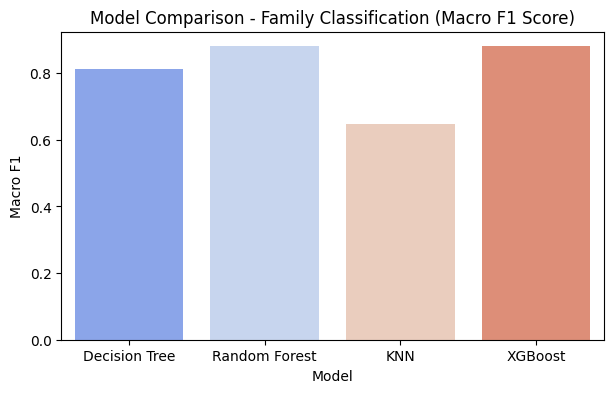


📊 Model Performance Summary:
Decision Tree: 0.8127
Random Forest: 0.8803
KNN: 0.6488
XGBoost: 0.8804


In [135]:

from sklearn.metrics import f1_score

models_fam_results = {
    "Decision Tree": f1_score(y_true_fam_dt, y_pred_fam_dt, average='macro'),
    "Random Forest": f1_score(y_true_fam_rf, y_pred_fam_rf, average='macro'),
    "KNN": f1_score(y_true_fam_knn, y_pred_fam_knn, average='macro'),
    "XGBoost": f1_score(y_true_fam_xgb, y_pred_fam_xgb, average='macro')
}

plt.figure(figsize=(7,4))
sns.barplot(x=list(models_fam_results.keys()), y=list(models_fam_results.values()), palette="coolwarm")
plt.title("Model Comparison - Family Classification (Macro F1 Score)")
plt.ylabel("Macro F1")
plt.xlabel("Model")
plt.show()

print("\n📊 Model Performance Summary:")
for model, score in models_fam_results.items():
    print(f"{model}: {score:.4f}")


In [136]:

from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

cols_to_drop = [col for col in ['Family', 'Class', 'md5', 'sha1'] if col in df.columns]
X_fam = df.drop(columns=cols_to_drop)
y_fam = df['Family']

for col in X_fam.select_dtypes(include='object').columns:
    le_col = LabelEncoder()
    X_fam[col] = le_col.fit_transform(X_fam[col])

X_train_fam, X_test_fam, y_train_fam, y_test_fam = train_test_split(
    X_fam, y_fam, test_size=0.2, stratify=y_fam, random_state=42
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_fam, y_train_fam)

print("Before SMOTE:", y_train_fam.value_counts().head(5).to_dict())
print("After SMOTE:", pd.Series(y_train_res).value_counts().head(5).to_dict())

scaler_fam = StandardScaler()
X_train_scaled = scaler_fam.fit_transform(X_train_res)
X_test_scaled = scaler_fam.transform(X_test_fam)

le_fam = LabelEncoder()
y_train_res_enc = le_fam.fit_transform(y_train_res)
y_test_fam_enc = le_fam.transform(y_test_fam)


Before SMOTE: {'Benign': 8700, 'Phobos': 440, 'Snake': 421, 'NanoCore': 416, 'Raccoon': 414}
After SMOTE: {'Benign': 8700, 'DarkSide': 8700, 'Gandcrab': 8700, 'WannaCry': 8700, 'REvil': 8700}


In [137]:

from sklearn.ensemble import RandomForestClassifier
import numpy as np

selector_model = RandomForestClassifier(n_estimators=100, random_state=42)
selector_model.fit(X_train_scaled, y_train_res_enc)

importances = selector_model.feature_importances_
top_k = 10
indices = np.argsort(importances)[-top_k:]

X_train_sel = X_train_scaled[:, indices]
X_test_sel = X_test_scaled[:, indices]
print(f"Selected top {top_k} important features for family classification.")


Selected top 10 important features for family classification.


In [138]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, f1_score

dt_family = DecisionTreeClassifier(max_depth=20, min_samples_split=5, random_state=42)
dt_family.fit(X_train_sel, y_train_res_enc)
y_pred_dt = dt_family.predict(X_test_sel)

y_pred_dt_labels = le_fam.inverse_transform(y_pred_dt)
y_test_labels = le_fam.inverse_transform(y_test_fam_enc)

print("\n--- Decision Tree (Family Classification) ---")
print(classification_report(y_test_labels, y_pred_dt_labels))
print("Macro F1:", f1_score(y_test_labels, y_pred_dt_labels, average='macro'))



--- Decision Tree (Family Classification) ---
              precision    recall  f1-score   support

  Agenttesla       1.00      1.00      1.00        67
      Benign       1.00      1.00      1.00      2176
      Cerber       0.98      0.92      0.95        66
    DarkSide       0.94      0.94      0.94        67
      Dharma       0.96      0.94      0.95       101
      Emotet       0.94      0.96      0.95        69
    Formbook       0.92      0.88      0.90        95
    Gandcrab       0.85      0.96      0.90        76
       Gh0st       0.87      0.90      0.89        91
    Glupteba       0.93      0.97      0.95        69
    Guloader       0.97      0.97      0.97        89
     LockBit       0.95      0.91      0.93        88
        Maze       0.95      0.97      0.96        58
    NanoCore       0.81      0.85      0.83       104
      Phobos       0.94      0.97      0.96       110
        Qbot       0.95      0.94      0.94        64
       REvil       0.94      0.96 

In [139]:

rf_family = RandomForestClassifier(
    n_estimators=300, max_depth=25, min_samples_split=5, class_weight='balanced', random_state=42
)
rf_family.fit(X_train_sel, y_train_res_enc)
y_pred_rf = rf_family.predict(X_test_sel)

y_pred_rf_labels = le_fam.inverse_transform(y_pred_rf)

print("\n--- Random Forest (Family Classification) ---")
print(classification_report(y_test_labels, y_pred_rf_labels))
print("Macro F1:", f1_score(y_test_labels, y_pred_rf_labels, average='macro'))



--- Random Forest (Family Classification) ---
              precision    recall  f1-score   support

  Agenttesla       1.00      1.00      1.00        67
      Benign       1.00      1.00      1.00      2176
      Cerber       0.98      0.95      0.97        66
    DarkSide       0.96      0.99      0.97        67
      Dharma       0.99      0.99      0.99       101
      Emotet       0.96      1.00      0.98        69
    Formbook       0.93      0.95      0.94        95
    Gandcrab       0.93      0.99      0.96        76
       Gh0st       0.93      0.93      0.93        91
    Glupteba       0.99      0.99      0.99        69
    Guloader       0.98      0.98      0.98        89
     LockBit       0.96      1.00      0.98        88
        Maze       0.97      0.98      0.97        58
    NanoCore       0.85      0.87      0.86       104
      Phobos       0.96      0.98      0.97       110
        Qbot       1.00      0.95      0.98        64
       REvil       0.99      0.97 

In [140]:

from sklearn.neighbors import KNeighborsClassifier

knn_family = KNeighborsClassifier(n_neighbors=5)
knn_family.fit(X_train_sel, y_train_res_enc)
y_pred_knn = knn_family.predict(X_test_sel)

y_pred_knn_labels = le_fam.inverse_transform(y_pred_knn)

print("\n--- KNN (Family Classification) ---")
print(classification_report(y_test_labels, y_pred_knn_labels))
print("Macro F1:", f1_score(y_test_labels, y_pred_knn_labels, average='macro'))



--- KNN (Family Classification) ---
              precision    recall  f1-score   support

  Agenttesla       1.00      1.00      1.00        67
      Benign       1.00      1.00      1.00      2176
      Cerber       0.94      0.91      0.92        66
    DarkSide       0.90      0.94      0.92        67
      Dharma       0.96      0.94      0.95       101
      Emotet       0.89      0.91      0.90        69
    Formbook       0.87      0.92      0.89        95
    Gandcrab       0.92      0.92      0.92        76
       Gh0st       0.83      0.87      0.85        91
    Glupteba       0.92      1.00      0.96        69
    Guloader       0.98      0.96      0.97        89
     LockBit       0.94      0.85      0.89        88
        Maze       0.90      0.95      0.92        58
    NanoCore       0.71      0.76      0.73       104
      Phobos       0.95      0.97      0.96       110
        Qbot       0.91      0.92      0.91        64
       REvil       0.89      0.93      0.91 

In [141]:

from xgboost import XGBClassifier

xgb_family = XGBClassifier(
    eval_metric='mlogloss',
    n_estimators=400,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_family.fit(X_train_sel, y_train_res_enc)
y_pred_xgb = xgb_family.predict(X_test_sel)

y_pred_xgb_labels = le_fam.inverse_transform(y_pred_xgb)

print("\n--- XGBoost (Family Classification) ---")
print(classification_report(y_test_labels, y_pred_xgb_labels))
print("Macro F1:", f1_score(y_test_labels, y_pred_xgb_labels, average='macro'))



--- XGBoost (Family Classification) ---
              precision    recall  f1-score   support

  Agenttesla       1.00      1.00      1.00        67
      Benign       1.00      1.00      1.00      2176
      Cerber       0.98      0.95      0.97        66
    DarkSide       0.97      0.99      0.98        67
      Dharma       1.00      0.98      0.99       101
      Emotet       1.00      0.97      0.99        69
    Formbook       0.95      0.94      0.94        95
    Gandcrab       0.95      0.99      0.97        76
       Gh0st       0.93      0.91      0.92        91
    Glupteba       0.97      0.99      0.98        69
    Guloader       0.98      1.00      0.99        89
     LockBit       0.97      0.99      0.98        88
        Maze       0.98      0.98      0.98        58
    NanoCore       0.87      0.89      0.88       104
      Phobos       0.97      0.98      0.98       110
        Qbot       0.97      0.97      0.97        64
       REvil       0.96      0.96      0

C:\Users\Keerthi\AppData\Local\Temp\ipykernel_2416\3972908673.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(models_fam.keys()), y=list(models_fam.values()), palette="coolwarm")


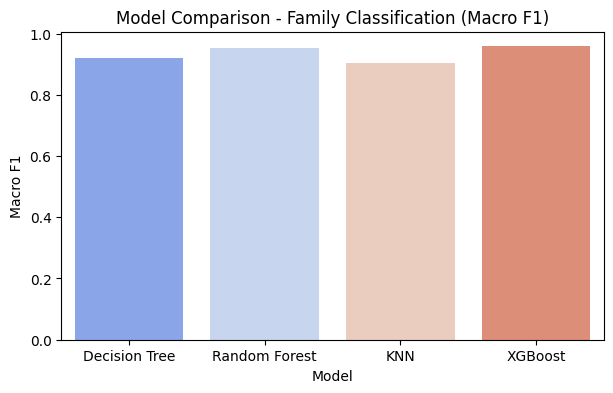


Model Performance Summary:
Decision Tree: 0.9212
Random Forest: 0.9521
KNN: 0.9029
XGBoost: 0.9580


In [142]:

models_fam = {
    "Decision Tree": f1_score(y_test_labels, y_pred_dt_labels, average='macro'),
    "Random Forest": f1_score(y_test_labels, y_pred_rf_labels, average='macro'),
    "KNN": f1_score(y_test_labels, y_pred_knn_labels, average='macro'),
    "XGBoost": f1_score(y_test_labels, y_pred_xgb_labels, average='macro')
}

plt.figure(figsize=(7,4))
sns.barplot(x=list(models_fam.keys()), y=list(models_fam.values()), palette="coolwarm")
plt.title("Model Comparison - Family Classification (Macro F1)")
plt.ylabel("Macro F1")
plt.xlabel("Model")
plt.show()

print("\nModel Performance Summary:")
for model, score in models_fam.items():
    print(f"{model}: {score:.4f}")


In [143]:
import numpy as np

label_map = {0: "Benign", 1: "Ransomware"}

sample_index = np.random.randint(0, len(X_selected))
sample_det = X_selected.iloc[[sample_index]]

pred_det = xgb_class.predict(sample_det)[0]
pred_det_label = label_map.get(int(pred_det), str(pred_det))

print(f"\nDetection Stage")
print(f"Sample Index: {sample_index}")
print(f"Predicted Detection Label: {pred_det_label}")


Detection Stage
Sample Index: 7182
Predicted Detection Label: Benign


In [144]:
sample_index_fam = np.random.randint(0, len(X_test_fam))

sample_fam = X_test_fam.iloc[[sample_index_fam]]
sample_fam_scaled = scaler_fam.transform(sample_fam)
sample_fam_selected = sample_fam_scaled[:, indices]

pred_fam_enc = xgb_family.predict(sample_fam_selected)[0]
pred_fam_label = le_fam.inverse_transform([pred_fam_enc])[0]

print(f"\nFamily Classification Stage")
print(f"Sample Index: {sample_index_fam}")
print(f"Predicted Family: {pred_fam_label}")


Family Classification Stage
Sample Index: 1059
Predicted Family: Emotet


In [145]:
def predict_pipeline_final():
    """Performs detection + family classification (using trained models)."""
    label_map = {0: "Benign", 1: "Ransomware"}

    det_index = np.random.randint(0, len(X_selected))
    sample_det = X_selected.iloc[[det_index]]
    pred_det = xgb_class.predict(sample_det)[0]
    pred_det_label = label_map.get(int(pred_det), str(pred_det))

    print(f"\nDetection Stage")
    print(f"Detection Sample Index: {det_index}")
    print(f"Detected As: {pred_det_label}")

    if pred_det_label.lower() == "benign":
        print("Benign file No ransomware family detected.")
    else:
        fam_index = np.random.randint(0, len(X_test_fam))
        sample_fam = X_test_fam.iloc[[fam_index]]
        sample_fam_scaled = scaler_fam.transform(sample_fam)
        sample_fam_selected = sample_fam_scaled[:, indices]

        pred_fam_enc = xgb_family.predict(sample_fam_selected)[0]
        pred_fam_label = le_fam.inverse_transform([pred_fam_enc])[0]

        print(f"\nFamily Classification Stage")
        print(f"Family Sample Index: {fam_index}")
        print(f"Ransomware Detected → Family: {pred_fam_label}")

In [146]:
predict_pipeline_final()


Detection Stage
Detection Sample Index: 2003
Detected As: Benign
Benign file No ransomware family detected.


In [147]:
import joblib

joblib.dump(xgb_class, "xgb_class.pkl")
joblib.dump(xgb_family, "xgb_family.pkl")
joblib.dump(scaler_fam, "scaler_fam.pkl")
joblib.dump(le_fam, "le_fam.pkl")
joblib.dump(indices, "feature_indices.pkl")
print("Models and preprocessors saved successfully.")

Models and preprocessors saved successfully.
